# Characterization-based Error Mitigation for Quantum Computation - Workshop

### Abstract
In this lab, you will learn about **Quantum Error Suppression and Error Mitigation (QESEM)** through hands-on experiments.
With QESEM, users can run quantum circuits on noisy QPUs and obtain highly accurate, error-free results with minimal QPU time overhead, close to theoretical limits.
When executing a circuit, QESEM runs a device characterization protocol tailored to your circuit, yielding a reliable noise model for the errors occurring in the circuit. Based on the characterization, QESEM first implements noise-aware transpilation to map the input circuit onto a set of physical qubits and gates, which minimizes the noise affecting the target observable. These include the natively available gates (CX/CZ on IBM® devices), as well as additional gates optimized by QESEM, forming QESEM’s extended gate set. QESEM then runs a set of characterization-based error suppression (ES) and error mitigation (EM) circuits on the QPU and collects their measurement outcomes. These are then classically post-processed to provide an unbiased expectation value and an error bar for each observable, corresponding to the requested accuracy.

For a detailed description of the QESEM algorithm, see our recent [paper](https://arxiv.org/abs/2508.10997) and the [QESEM documentation](https://docs.qedma.io/).

<div>
<img src="Qesem_workflow.svg" width="800"/>
</div>

## Setup
We will run the workshop using google colab.

Instead, if you prefer, you can clone the [repository](https://github.com/Qedma/qip-2026-qesem-workshop) and install the required packages locally using `pip` or `poetry`.

Use the following commands to clone the repository and install the required packages.

In [ ]:
!git clone https://github.com/Qedma/qip-2026-qesem-workshop.git

In [ ]:
!pip install "qiskit>=2.0.0" "qiskit-ibm-runtime>=0.40.0" "qiskit-aer>=0.17.1" "networkx>=3.5" "matplotlib==3.10.0" "tqdm>=4.67.1" "scipy" "numpy" "qedma-api==0.18.3"

# In case you are running locally, please install jupyter as well:
# pip install "jupyter>=1.1.1"

In [ ]:
cd /content/qip-2026-qesem-workshop

# Imports

In [97]:
%matplotlib inline

import datetime
import math
import time

import grader
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import qedma_api
import qiskit
import qiskit.converters
import qiskit.quantum_info
import qiskit.result
import qiskit_aer
import qiskit_aer.noise
import qiskit_ibm_runtime.fake_provider
import scipy.optimize
import tqdm
import utils

## Learning Objectives

We'll explore:

1. **Why do we need error mitigation?** - See how quantum noise affects different types of measurements
2. **Kicked Ising circuits** - Our main example is the Kicked Ising chain, a benchmark model in quantum dynamics
3. **Using QESEM** - Use QESEM to mitigate the noise

# Table of Contents

1. [Section 1: Understanding the Importance of Error Mitigation](#Section-1:-Understanding-the-Importance-of-Error-Mitigation)
   - [1.1 Use Case: Kicked Ising](#1.1-Use-Case:-Kicked-Ising)
   - [1.2 Exercise 1: Comparing Ideal and Noisy Values](#1.2-Exercise-1:-Comparing-Ideal-and-Noisy-Values)
     <!-- - [a. Trotter Circuit Visualization](#exercise-1a)
     - [b. Ideal VS Noisy](#exercise-1b)
       - [i. Total Magnetization](#exercise-1b-i)
       - [ii. Heavy Weight (zzz)](#exercise-1b-ii) -->
2. [Section 2: Introduction to QESEM](#Section-2:-Introduction-to-QESEM)
   - [QESEM Parameters Reference](#QESEM-Parameters-Reference)
   - [2.1 Exercise 2: Applying QESEM on a simple circuit](#2.1-Exercise-2:-Applying-QESEM-on-a-simple-circuit)
     <!-- - [a. Time Estimation (Analytical + Empirical)](#exercise-2a)
     - [b. Execution](#exercise-2b)
     - [c. Reading Results](#exercise-2c)
     - [d. Execution Metrics](#exercise-2d) -->
   - [2.2 Key Concepts](#2.2-Key-Concepts)
     - [2.2.1 Volume and Active Volume](#2.2.1-Volume-and-Active-Volume)
     - [2.2.2 QESEM Runtime Overhead](#2.2.2-QESEM-Runtime-Overhead)
   - [2.3 Exercise 3: QPU time vs. Active Volume](#2.3-Exercise-3:-QPU-time-vs.-Active-Volume)
     <!-- - [a. Observables vs QPU Time](#exercise-3a)
     - [b. Influence of Angles](#exercise-3b) -->
   - [2.4 Exercise 4: Exploring the $T\propto\frac{1}{\varepsilon^2}$ Relationship](#2.4-Exercise-4:-Exploring-the-$T-\propto-\frac{1}{\varepsilon^2}$-Relationship)
     <!-- - [a. Mitigation Overhead vs 𝜖](#exercise-4a) -->

# Section 1: Understanding the Importance of Error Mitigation

Quantum computers are inherently noisy devices. Even small amounts of noise can significantly affect quantum computations, especially as circuit depth increases. In this section, we'll:

1. **Build a circuit** for the Kicked Ising model
2. **Learn the effects of noise** on different types of quantum observables

## 1.1 Use Case: Kicked Ising

The **Kicked Ising Model** is a paradigmatic quantum spin chain model used to study quantum chaos, entanglement, and non-equilibrium dynamics. It consists of spin-1/2 particles (qubits) with nearest-neighbor interactions on a graph, and a periodically applied "kick".

### Model Definition

The time evolution of the kicked Ising model is governed by a periodically time-dependent Hamiltonian. The unitary evolution over one period $T$, on a 1D lattice of size $n$, is given by:

$$
U = \exp\left(-i J \sum_{j=0}^{n-2} \sigma_j^z \sigma_{j+1}^z \right) \exp\left(-i h_x \sum_{j=0}^{n-1} \sigma_j^x \right)
$$

where $\sigma_j^x, \sigma_j^z$ are Pauli matrices acting on site $j$, and $J, h_x$ are constants.

### Physical Significance

- **Quantum Chaos:** The kicked Ising model exhibits rich quantum chaotic behavior, making it a benchmark for studies of thermalization and information scrambling in many-body quantum systems.
- **Floquet Systems:** Since the system is driven periodically, it is a canonical example of a **Floquet system**, where stroboscopic (periodic) dynamics are studied.
- **Entanglement & Quantum Information:** The model is widely used to investigate entanglement growth, operator spreading, and out-of-time-ordered correlators (OTOCs).

### Applications

- Modeling non-equilibrium quantum dynamics.
- Studying quantum information scrambling and entanglement spreading.
- Exploring the transition between integrability and chaos in quantum systems.

---

**References:**
- Prosen, T. (2007). "Chaos and complexity in a kicked Ising spin chain." *Phys. Rev. E* 65, 036208.
- [Wikipedia: Kicked Ising Model](https://en.wikipedia.org/wiki/Kicked_Ising_model)

<div class="alert alert-block alert-info">
<b>Note:</b>

While in this lab we focus on exploring a 1D Kicked Ising model for simplicity, QESEM can work on arbitrary circuits and observables.

## 1.2 Exercise 1: Comparing Ideal and Noisy Values

This exercise demonstrates how quantum noise degrades computation results by comparing three scenarios:

**What We'll Do:**
- **Build Kicked Ising Circuits**: Create quantum circuits simulating time evolution with increasing number of Trotter steps
- **Measure Observables**:
  - **Z Correlation Operators**: Evaluate  $\left\langle Z_0 Z_1 \dots Z_{n-1} \right\rangle$ and $\left\langle Z_0 Z_1 \dots Z_{4} \right\rangle$ to probe global multi-qubit correlations
- **Compare Results**: Ideal expectation values to noisy ones


### Step 1: Preparing Kicked-Ising circuit

utils.kicked_ising_1d: Creates a quantum circuit that implements the Kicked Ising model. It applies alternating layers of RX gates (transverse field) and RZZ gates (interaction terms) to simulate the time evolution of the system.

In [63]:
def kicked_ising_1d(num_qubits: int, theta_x: float, theta_zz: float, num_steps: int) -> qiskit.QuantumCircuit:
    """
    Parameters:
        num_qubits (int): number of qubits on chain.
        theta_x (float): Angle for RX gates.
        theta_zz (float): Angle for RZZ gates.
        num_steps (int): Number of steps.

    Returns:
        QuantumCircuit: The resulting quantum circuit.
    """
    graph = nx.path_graph(num_qubits)
    qc = qiskit.QuantumCircuit(num_qubits)

    # Precompute edge layers (alternating non-overlapping pairs)
    edges = list(graph.edges())
    even_edges = [(u, v) for (u, v) in edges if u % 2 == 0]
    odd_edges = [(u, v) for (u, v) in edges if u % 2 == 1]

    for step in range(num_steps):
        # RX on all qubits
        for q in range(num_qubits):
            qc.rx(theta_x, q)

        # Apply even and odd layers separately
        for edge_layer in [even_edges, odd_edges]:
            for u, v in edge_layer:
                qc.rzz(theta_zz, u, v)

        if step < num_steps - 1:
            qc.barrier()

    return qc

### Step 2: Kicked Ising Circuit Visualization

Here we set up the circuit experiment parameters and create a visualization of the circuit.


In [3]:
n_qubits_ex1 = 20
n_steps = 3

circ = kicked_ising_1d(n_qubits_ex1, theta_x=math.pi / 6, theta_zz=math.pi / 3, num_steps=n_steps)

print(f"Circuit 2q layers: {circ.depth(filter_function=lambda instr: len(instr.qubits) == 2)}")
print("\nCircuit structure:")

circ.draw("text", scale=0.8, fold=-1)

Circuit 2q layers: 6

Circuit structure:


┌─────────┐                     ░ ┌─────────┐                     ░ ┌─────────┐                    
 q_0: ┤ Rx(π/6) ├─■───────────────────░─┤ Rx(π/6) ├─■───────────────────░─┤ Rx(π/6) ├─■──────────────────
      ├─────────┤ │ZZ(π/3)            ░ ├─────────┤ │ZZ(π/3)            ░ ├─────────┤ │ZZ(π/3)           
 q_1: ┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■────────
      ├─────────┤           │ZZ(π/3)  ░ ├─────────┤           │ZZ(π/3)  ░ ├─────────┤           │ZZ(π/3) 
 q_2: ┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■────────
      ├─────────┤ │ZZ(π/3)            ░ ├─────────┤ │ZZ(π/3)            ░ ├─────────┤ │ZZ(π/3)           
 q_3: ┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■────────
      ├─────────┤           │ZZ(π/3)  ░ ├─────────┤           │ZZ(π/3)  ░ ├─────────┤           │ZZ(π/3) 
 q_4: ┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■────────
      ├─────────┤ │ZZ(π/3)            ░ ├─────────┤ │ZZ(π/3)            ░ ├─────────┤ │ZZ(π/3)           
 q_5: ┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■────────
      ├─────────┤           │ZZ(π/3)  ░ ├─────────┤           │ZZ(π/3)  ░ ├─────────┤           │ZZ(π/3) 
 q_6: ┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■────────
      ├─────────┤ │ZZ(π/3)            ░ ├─────────┤ │ZZ(π/3)            ░ ├─────────┤ │ZZ(π/3)           
 q_7: ┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■────────
      ├─────────┤           │ZZ(π/3)  ░ ├─────────┤           │ZZ(π/3)  ░ ├─────────┤           │ZZ(π/3) 
 q_8: ┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■────────
      ├─────────┤ │ZZ(π/3)            ░ ├─────────┤ │ZZ(π/3)            ░ ├─────────┤ │ZZ(π/3)           
 q_9: ┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■────────
      ├─────────┤           │ZZ(π/3)  ░ ├─────────┤           │ZZ(π/3)  ░ ├─────────┤           │ZZ(π/3) 
q_10: ┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■────────
      ├─────────┤ │ZZ(π/3)            ░ ├─────────┤ │ZZ(π/3)            ░ ├─────────┤ │ZZ(π/3)           
q_11: ┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■────────
      ├─────────┤           │ZZ(π/3)  ░ ├─────────┤           │ZZ(π/3)  ░ ├─────────┤           │ZZ(π/3) 
q_12: ┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■────────
      ├─────────┤ │ZZ(π/3)            ░ ├─────────┤ │ZZ(π/3)            ░ ├─────────┤ │ZZ(π/3)           
q_13: ┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■────────
      ├─────────┤           │ZZ(π/3)  ░ ├─────────┤           │ZZ(π/3)  ░ ├─────────┤           │ZZ(π/3) 
q_14: ┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■────────
      ├─────────┤ │ZZ(π/3)            ░ ├─────────┤ │ZZ(π/3)            ░ ├─────────┤ │ZZ(π/3)           
q_15: ┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■────────
      ├─────────┤           │ZZ(π/3)  ░ ├─────────┤           │ZZ(π/3)  ░ ├─────────┤           │ZZ(π/3) 
q_16: ┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■────────
      ├─────────┤ │ZZ(π/3)            ░ ├─────────┤ │ZZ(π/3)            ░ ├─────────┤ │ZZ(π/3)           
q_17: ┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■────────
      ├─────────┤           │ZZ(π/3)  ░ ├─────────┤           │ZZ(π/3)  ░ ├─────────┤           │ZZ(π/3) 
q_18: ┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) 

### Step 3: Simulation Parameters

Here we define:

1. A list of circuits to simulate (corresponding to the different number of time steps)
2. A list of observables to measure: $\langle Z_0...Z_4 \rangle$ and $\langle Z_0...Z_{n-1} \rangle$ and their labels


In [4]:
steps_range = range(1, 9)

circs_ex1 = []
for n_steps in steps_range:
    circs_ex1.append(
        kicked_ising_1d(
            n_qubits_ex1,
            theta_x=math.pi * 0.14,
            theta_zz=math.pi * 0.05,
            num_steps=n_steps,
        )
    )

# Prepare pairs of  (observables , labels)
observable_label_pairs = [
    (qiskit.quantum_info.SparsePauliOp.from_sparse_list([("Z" * 5, range(5), 1)], n_qubits_ex1), r"$Z_0Z_1...Z_{4}$"),
    (qiskit.quantum_info.SparsePauliOp.from_sparse_list([("Z" * n_qubits_ex1, range(n_qubits_ex1), 1)], n_qubits_ex1), r"$Z_0Z_1...Z_{n-1}$"),
]

### Step 4: Compute ideal values

Here we compute the ideal expectation values for each observable using exact simulation with statevectors. <br>
This gives us the theoretical values that we would obtain on a perfect quantum computer without any noise.

The following dictionary holds the ideal/noisy expectation values for every observable per step:<br>
graphs["ideal" or "noisy"][observable label] = [Expectation of observable at steps_range[0], Expectation of observable at steps_range[1], ....]

<div class="alert alert-block alert-success">
<b>Exercise 1.1:</b> <br>
    Complete the code for computing the ideal expectation value of "obs" after running the circuit "circ"

Hint: [Statevector Documentation](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.quantum_info.Statevector)

In [5]:
graphs = {"ideal": {}}
graphs["ideal"]["steps_range"] = steps_range
for circ in tqdm.tqdm(circs_ex1):  # Loop over circuits [one step circuit, two steps circuit ,....]
    for obs, label in observable_label_pairs:  # Loop over observables and their label
        if label not in graphs["ideal"]:  # Create list of ideal expectation values for every circuit
            graphs["ideal"][label] = []
        ideal_value = qiskit.quantum_info.Statevector(circ).expectation_value(obs).real
        graphs["ideal"][label].append(ideal_value)

100%|██████████| 8/8 [00:10<00:00,  1.27s/it]


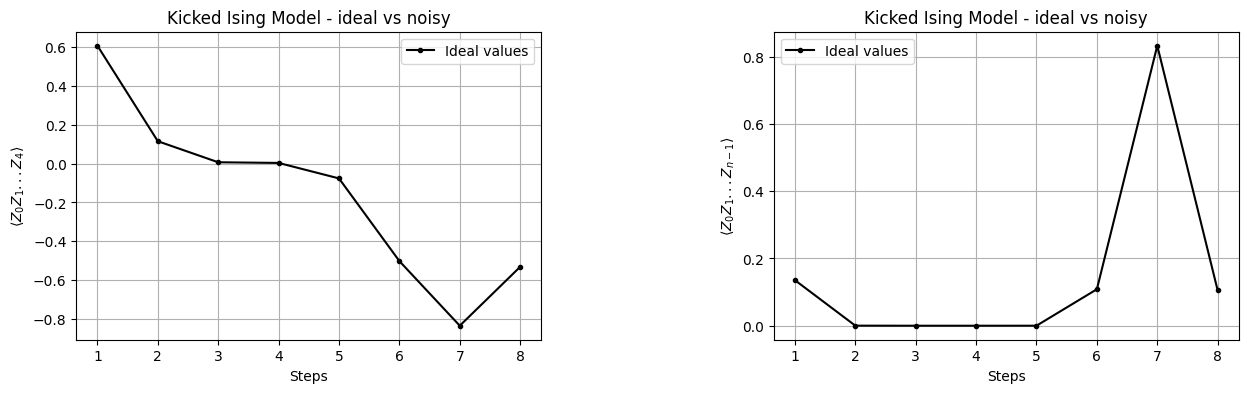

In [6]:
# Function to draw graphs from "graphs" object

# Running the function
utils.graph_plots(graphs, observable_label_pairs)

<div class="alert alert-block alert-info">
<b>Build Intuition:</b>

Which of the two observables will be more affected by noise?

### Step 5: Compute noisy values with error bars

Let's add **realistic quantum noise** to our simulation. We'll use an AerSimulator based on IBM's Fake Fez backend, which includes realistic noise models based on actual quantum hardware. <br>

In [7]:
fake_backend = qiskit_ibm_runtime.fake_provider.FakeFez()
basis_gates = fake_backend.configuration().basis_gates

noisy_backend = qiskit_aer.AerSimulator(
    method="matrix_product_state",
    noise_model=qiskit_aer.noise.NoiseModel.from_backend(fake_backend),
    basis_gates=basis_gates,
    coupling_map=fake_backend.configuration().coupling_map,
    properties=fake_backend.properties(),
    device="GPU" if "GPU" in qiskit_aer.AerSimulator().available_devices() else "CPU",
)


num_shots = 100  #### <------ Edit if too slow

Let's compute the noisy expectation values by running the circuits on the noisy simulator with finite shots. We calculate both the expectation values and their standard deviations to understand the statistical uncertainty in our measurements.

<div class="alert alert-block alert-success">
<b>Exercise 1.2:</b> <br>
    Complete the code for running "num_shots" shots of "transpiled_circ" on "noisy_backend" and extract the "counts" dictionary from the result. <br>
Change the number of shots if the simulation is too slow.<br>

Hint: [AerSimulator Documentation](https://qiskit.github.io/qiskit-aer/tutorials/1_aersimulator.html)

In [8]:
graphs["noisy"] = {"steps_range": steps_range}
graphs["noisy_std"] = {}

for circ in tqdm.tqdm(circs_ex1):
    transpiled_circ = qiskit.transpile(circ, basis_gates=basis_gates, coupling_map=fake_backend.coupling_map)
    transpiled_circ = utils.remove_idle_qubits(transpiled_circ)

    transpiled_circ.measure_all()
    counts = noisy_backend.run(transpiled_circ, shots=num_shots).result().get_counts()

    for obs, label in observable_label_pairs:
        if label not in graphs["noisy"]:
            graphs["noisy"][label] = []
            graphs["noisy_std"][label] = []

        noisy_obs_expectation = qiskit.result.sampled_expectation_value(counts, obs)  # Convert counts to expectation value
        noisy_obs_variance = (1 - qiskit.result.sampled_expectation_value(counts, obs) ** 2) / num_shots  # Only true for Paulis: P^2=I
        graphs["noisy"][label].append(noisy_obs_expectation)
        graphs["noisy_std"][label].append(noisy_obs_variance**0.5)

100%|██████████| 8/8 [00:23<00:00,  3.00s/it]


### Step 6: Plot the results

Finally, we visualize the results by plotting both the ideal and noisy expectation values as a function of the number of Trotter steps.

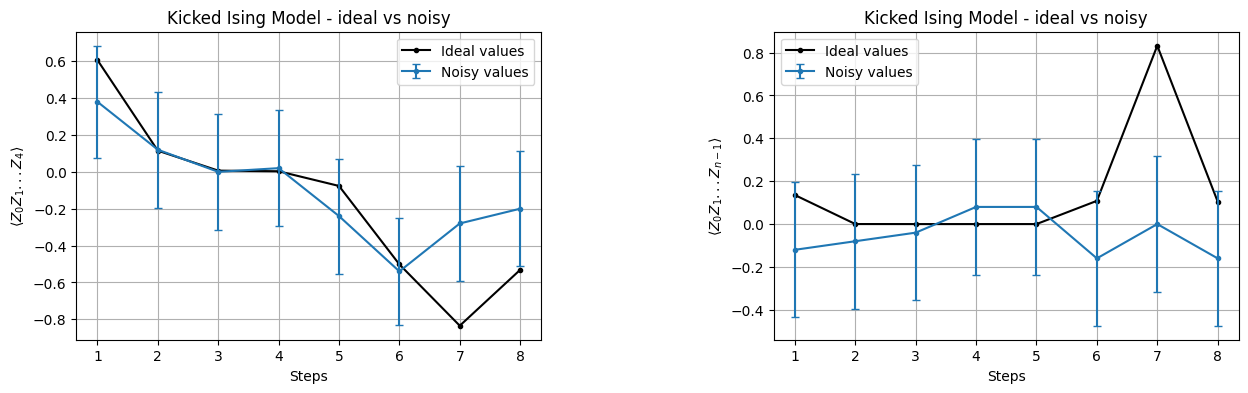

In [9]:
utils.graph_plots(graphs, observable_label_pairs)

<div class="alert alert-block alert-info">
<b>Build intuition:</b> <br>


- As circuits get deeper, quantum noise accumulates and the gap between ideal and noisy values grows. QESEM allows to run deeper circuits and still get meaningful results.
- The decay of the noisy value is controlled by the number of noisy operations the observable is sensitive to. The $\langle Z0...Z19 \rangle$ observable decays much more than $\langle Z0...Z4 \rangle$ because its lightcone spans the entire circuit.

# Section 2: Introduction to QESEM

Now that we've seen how dramatically noise affects quantum computations, let's explore **QESEM** - a powerful technique to reduce these errors.

### How QESEM Works

QESEM combines two approaches:

1. **Error Suppression**: Reduce the unitary part of the noise. It is based on QESEM's characterization.
2. **Error Mitigation**: Use classical post-processing to estimate what the results would have been without noise.

### QESEM Parameters Reference
During this section we will guide you through the main parameters and explain each one.
There are more advanced parameters which we won't cover, see an elaborate explanation about all the parameters [here](https://docs.qedma.io/advanced_settings/).

## 2.1 Exercise 2: Applying QESEM on a simple circuit

### Step 1: Initialize qedma_api client

Here we are initializing the qedma_api client for an IBMQ simulator backend.
Note: this API token will be available during QIP 2026 for you to explore QESEM on IBMQ simulators. For using QESEM on real QPUs please contact us at Qedma.

In [109]:
# configuration
# todo add your token here
qedma_api_token = "mmW_dHllhERPRyiZ-XhIfKN8mzuqnQ4EwmeIJHyITyg"
ibm_instance = "crn:v1:bluemix:public:quantum-computing:us-east:a/e04323988bc6476ea650cb531d87b412:4270fa45-5a7c-46cf-8667-d2b1779d2227::"

qedma_client = qedma_api.Client(api_token=qedma_api_token)
provider = qedma_api.IBMQProvider(instance=ibm_instance)
qedma_client.set_provider(provider)

In [110]:
# please enter a job description prefix for you jobs, e.g. your name
job_description_prefix = "job_description_prefix"

### Step 2: Prepare Circuit and Observables
The following circuit prepares the state $|\psi\rangle = 0.6|0000\rangle+0.8|1111\rangle $

We will measure two observables:<br>
avg_magnetization_ex2 = $\frac{1}{4} \sum_j Z_j$ <br>
all_z_ex2 = $Z_0...Z_3$

In [111]:
circ_ex2 = qiskit.QuantumCircuit(4)
circ_ex2.ry(0.927 * 2, 0)
circ_ex2.cx(0, 1)
circ_ex2.cx(1, 2)
circ_ex2.cx(2, 3)

avg_magnetization_ex2 = qiskit.quantum_info.SparsePauliOp.from_sparse_list([("Z", [q], 1 / 4) for q in range(4)], num_qubits=4)

all_z_ex2 = qiskit.quantum_info.SparsePauliOp.from_sparse_list([("Z" * 4, range(4), 1)], 4)

obs_list_ex2 = [avg_magnetization_ex2, all_z_ex2]


circ_ex2.draw("text", scale=0.7)

┌───────────┐               
q_0: ┤ Ry(1.854) ├──■────────────
     └───────────┘┌─┴─┐          
q_1: ─────────────┤ X ├──■───────
                  └───┘┌─┴─┐     
q_2: ──────────────────┤ X ├──■──
                       └───┘┌─┴─┐
q_3: ───────────────────────┤ X ├
                            └───┘

### Step 3: Empirical Time Estimation

Users would typically want to know how much QPU time is required for their experiment.
However, this is considered a hard problem for classical computers.<br>
QESEM offers two modes of time estimation to inform users about the feasibility of their experiments:
1. Analytical time estimation - gives a very rough estimation and requires no QPU time. This can be used to test if a transpilation pass would potentially reduce the QPU time.
2. Empirical time estimation (demonstrated here) - gives a pretty good estimation and uses a few minutes of QPU time.

In both cases, QESEM outputs the time estimation for reaching the required precision for <b>all</b> observables.

In [112]:
# Start a job for empirical time estimation


job = qedma_client.create_job(
    circuit=circ_ex2,
    observables=obs_list_ex2,
    empirical_time_estimation=True,  # "empirical" - gets actual time estimates without running full mitigation
    precision=0.1,  # Precision for all observables
    backend="fake_fez",  # E.g. "ibm_brisbane"
    description=f"{job_description_prefix}-ex2",
)
print(f"Your job ID is: {job.job_id}")

2026-01-27 16:59:09.148 | INFO     | Submitting new job
2026-01-27 16:59:10.604 | INFO     | [e74fb0b621674efbb42d5ad487d1538a] New job created
Your job ID is: e74fb0b621674efbb42d5ad487d1538a


In [113]:
# Wait for the empirical time estimation to complete. This takes a 1-3 minutes
time_estimation = qedma_client.wait_for_time_estimation(job.job_id)

2026-01-27 17:00:45.753 | INFO     | [e74fb0b621674efbb42d5ad487d1538a] Empirical time estimation: [5.0 minutes]


In [114]:
print(f"Empirical time estimation (sec): {time_estimation.seconds}")

Empirical time estimation (sec): 300


### Step 4: Use QESEM to estimate the expectation values

<div class="alert alert-block alert-success">
<b>Exercise 2:</b> <br>
    Use QESEM to estimate the expectation values of "avg_magnetization_ex2" and "all_z_ex2" observables on the state generated by circ_ex2.  <br>
    Start the job for which you ran the empirical time estimation above and set the max QPU time to 15 minutes. <br>


In [37]:
job_id_ex2 = job.job_id  # Use the job created above
max_qpu_time_ex2 = datetime.timedelta(minutes=15)

### Test parameters

In [38]:
message = grader.grade_ex2(job=job, job_id=job_id_ex2, max_qpu_time_ex2=max_qpu_time_ex2)
print(message)

Congratulations! 🎉 Your answer is correct.


In [39]:
# choose parameters for the start QESEM job:

qedma_client.start_job(
    job_id=job_id_ex2,
    max_qpu_time=max_qpu_time_ex2,
)

2026-01-27 13:34:29.038 | INFO     | [23595b838ce94f3c96e6e1f5c40e9dd8] Starting job


### Step 5: Reading the results

In [43]:
job_res = qedma_client.wait_for_job_complete(  # Blocking - takes 3-5 minutes
    job_id=job_id_ex2,
)

2026-01-27 14:31:15.003 | INFO     | [23595b838ce94f3c96e6e1f5c40e9dd8] step: [Queued]
2026-01-27 14:31:15.004 | INFO     | [23595b838ce94f3c96e6e1f5c40e9dd8] step: [Initial Transpilation]
2026-01-27 14:31:15.005 | INFO     | [23595b838ce94f3c96e6e1f5c40e9dd8] step: [Qubit Selection]
2026-01-27 14:31:15.006 | INFO     | [23595b838ce94f3c96e6e1f5c40e9dd8] step: [Calibration]
2026-01-27 14:31:15.010 | INFO     | [23595b838ce94f3c96e6e1f5c40e9dd8] step: [Characterization]
2026-01-27 14:31:15.011 | INFO     | [23595b838ce94f3c96e6e1f5c40e9dd8] step: [Batch Mitigation #1]
2026-01-27 14:31:15.011 | INFO     | [23595b838ce94f3c96e6e1f5c40e9dd8] Final results: [[[(<SparseObservable with 4 terms on 4 qubits: (0.25+0j)(Z_0) + (0.25+0j)(Z_1) + (0.25+0j)(Z_2) + (0.25+0j)(Z_3)>, QesemObservableResult(unmitigated=ExpectationValue(value=-0.28090000000000004, error_bar=0.010575766738410186), noise_scaling=NoiseScalingResult(scaling_method='QESEM', results_with_REM=[ScaleExpectationValue(value=-0.27705

In [57]:
# Names for the observables
observable_names = ["Average Magnetization", "ZZZZ"]

for circuit_result in job_res.results:
    for i, (observable, result) in enumerate(circuit_result):
        print("-" * 10)
        print(f"Observable name: {observable_names[i]}")
        print(f"Observable:      {observable}")
        print(f"Ideal:           {qiskit.quantum_info.Statevector(circ_ex2).expectation_value(obs_list_ex2[i]).real:.6f}")
        print(f"QESEM:           {result.qesem}")
        print(f"Unmitigated:     {result.unmitigated}")
        print()

print("-" * 10)
# Some of the data gathered during a QESEM run.
print(f"Gate fidelities found: {job_res.execution_details.gate_fidelities}")

----------
Observable name: Average Magnetization
Observable:      <SparseObservable with 4 terms on 4 qubits: (0.25+0j)(Z_0) + (0.25+0j)(Z_1) + (0.25+0j)(Z_2) + (0.25+0j)(Z_3)>
Ideal:           -0.279433
QESEM:           {ev: -0.27705209156859867 ± 0.0037973963816222193}
Unmitigated:     {ev: -0.28090000000000004 ± 0.010575766738410186}

----------
Observable name: ZZZZ
Observable:      <SparseObservable with 1 term on 4 qubits: (1+0j)(Z_3 Z_2 Z_1 Z_0)>
Ideal:           1.000000
QESEM:           {ev: 1.0010447983455646 ± 0.011799026856504961}
Unmitigated:     {ev: 0.9376000000000001 ± 0.003799168884180634}

----------
Gate fidelities found: {'CZ': 0.9952438963284183, 'ID1Q': 0.9994626072002313}


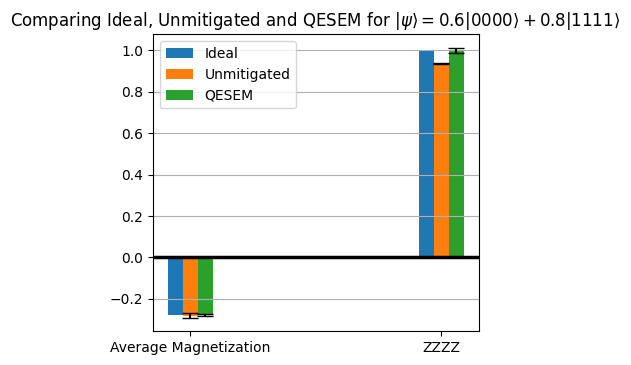

In [59]:
# Results as a graph
x = np.arange(2)  # Column position
width = 0.06

fig, ax = plt.subplots(figsize=(4, 2.5 * 1.5))

# Extract values from the new structure
ideal_values = [qiskit.quantum_info.Statevector(circ_ex2).expectation_value(obs).real for obs in [avg_magnetization_ex2, all_z_ex2]]
unmitigated_values = [job_res.results[0][i][1].unmitigated.value for i in range(2)]
unmitigated_errors = [job_res.results[0][i][1].unmitigated.error_bar for i in range(2)]
qesem_values = [job_res.results[0][i][1].qesem.value for i in range(2)]
qesem_errors = [job_res.results[0][i][1].qesem.error_bar for i in range(2)]

# Plot the bars side by side
ax.bar(x - width, ideal_values, width, label="Ideal")
ax.bar(x, unmitigated_values, width, label="Unmitigated", yerr=unmitigated_errors, capsize=6)
ax.bar(x + width, qesem_values, width, label="QESEM", yerr=qesem_errors, capsize=6)

ax.set_xticks(x)
ax.set_xticklabels(["Average Magnetization", "ZZZZ"])
ax.set_title(r"Comparing Ideal, Unmitigated and QESEM for $|\psi\rangle = 0.6|0000\rangle+0.8|1111\rangle$ ")
ax.legend()

plt.tight_layout()
plt.grid(axis="y")
plt.axhline(0, color="black", linewidth=2.5)  # y=0, bold black line
plt.show()

## 2.2 Key Concepts

### 2.2.1 Volume and Active Volume

A key figure of merit for quantifying the hardness of both error mitigation and classical simulation for a given circuit and observable is **active volume**: The number of two-qubit gates affecting the observable in the circuit. Different circuits and observables have different **active volumes**, which affects how hard they are to error-mitigate.

The active volume depends on:
- Circuit depth and width
- Observable weight (number of non-identity Pauli operators)
- Circuit structure (light cone of the observable)

For further details, see the talk from the [2024 IBM Quantum Summit](https://www.youtube.com/watch?v=Hd-IGvuARfE&t=1730s&ab_channel=IBMResearch).

<div>
<img src="active_vol.svg" />
</div>

### 2.2.2 QESEM Runtime Overhead

The QPU time behaves roughly like:
$$T_{QPU} \approx \left(\frac{A}{\epsilon^2}\right) \times e^{C \times IF \times V_{active}} + B$$
Where:
- B overhead of gate optimization and error characterization
- precision $\epsilon$ absolute error in expectation value
- $ IF \times V_{active} $ infidelity-per-gate times active volume. The active volume only includes gates within the active light-cone.

The **overhead** of error mitigation tells us how many additional quantum resources we need to achieve a target precision.

## 2.3 Exercise 2: QPU time vs. Active Volume
In this section we'll fix the number of steps and the precision, and compare the QPU time for the two observables in Exercise 1.


<div class="alert alert-block alert-success">
<b>Exercise 3:</b> <br>
    Use QESEM's <b>analytical</b> time estimation for measuring the expectation of $\langle Z_0...Z_4\rangle$ and $\langle Z_0...Z_{n-1}\rangle$ of the state generated by a few steps of the Kicked Ising model.<br>
    Set the default_precision to 0.02.



In [60]:
# Set the options parameter for the QESEM job by the instruction:

precision = 0.02
empirical_time_estimation = False

### Test parameters

In [61]:
message = grader.grade_ex3(precision, empirical_time_estimation)
print(message)

Congratulations! 🎉 Your answer is correct.


### Start a jobs only if parameter check passed

In [64]:
if message == grader.CORRECT_MESSAGE:
    print("Starting jobs")
    selected_step = 6  # number of steps in the circuit.
    num_qubits_ex3 = 20

    circ = kicked_ising_1d(
        num_qubits_ex3,
        theta_x=math.pi * 0.14,
        theta_zz=math.pi * 0.05,
        num_steps=selected_step,
    )

    # Prepare pairs of  (observables , labels)
    observable_label_pairs_ex3 = [
        (qiskit.quantum_info.SparsePauliOp.from_sparse_list([("Z" * 5, range(5), 1)], num_qubits_ex3), r"$Z_0Z_1...Z_{4}$"),
        (qiskit.quantum_info.SparsePauliOp.from_sparse_list([("Z" * num_qubits_ex3, range(num_qubits_ex3), 1)], num_qubits_ex3), r"$Z_0Z_1...Z_{n-1}$"),
    ]

    volume_jobs: list[datetime.timedelta] = []
    for observable, obs_label in observable_label_pairs_ex3:
        # run analytical time estimation on each observable separately. Takes about 3 minutes
        job = qedma_client.create_job(
            circuit=circ,
            observables=[observable],
            backend="fake_fez",
            precision=precision,
            empirical_time_estimation=empirical_time_estimation,
            description=f"{job_description_prefix}-ex3-{obs_label}",
        )
        time_est = qedma_client.wait_for_time_estimation(job.job_id)  # Wait for the time estimation to complete
        print(f"Analytical time estimation for observable {obs_label}: {time_est.seconds / 60} min")

else:
    print("Parameters check failed. Jobs did not start")

Starting jobs
2026-01-27 15:02:29.219 | INFO     | Submitting new job
2026-01-27 15:02:32.077 | INFO     | [f13a8311237249c48578ecd2cc92b6f1] New job created
2026-01-27 15:05:07.520 | INFO     | [f13a8311237249c48578ecd2cc92b6f1] Analytical time estimation: [30.0 minutes]
Analytical time estimation for observable $Z_0Z_1...Z_{4}$: 30.0 min
2026-01-27 15:05:07.525 | INFO     | Submitting new job
2026-01-27 15:05:09.970 | INFO     | [81d0ca1cdef24ce9b93fdbe2c25594d4] New job created
2026-01-27 15:05:30.969 | INFO     | [81d0ca1cdef24ce9b93fdbe2c25594d4] Analytical time estimation: [90.0 minutes]
Analytical time estimation for observable $Z_0Z_1...Z_{n-1}$: 90.0 min


<div class="alert alert-block alert-info">
<b>Build intuition:</b> While the analytical time estimation is very rough (resolution of 30 minutes) and pessimistic, it still captures the difference in the active volumes of the two observables fairly quickly, and without using any QPU time.

## 2.4 Exercise 4: Exploring the $T \propto \frac{1}{\varepsilon^2}$ Relationship

In this exercise, we will investigate **how QPU time scales with precision requirements**.
### Step 1: Create and visualize the test circuit

We'll create a single Kicked Ising circuit to test the precision-time relationship. This circuit will have enough complexity to show clear scaling behavior while remaining manageable for the experiment.

<div class="alert alert-block alert-success">

<b> Exercise 4.1:</b> <br>
Complete the code. Use the function kicked_ising_1d() defined in Exercise 1 to create the circuit circ_ex4. Be sure to use the variables defined below n_qubits_ex4, n_steps_ex4, theta_x_ex4, theta_zz_ex4.
</div>

In [65]:

n_qubits_ex4 = 5  # Number of qubits (enough to see scaling effects)
n_steps_ex4 = 10  # Number of Trotter steps (creates sufficient circuit depth)
theta_x_ex4 = math.pi / 6  # Rotation angle for X gates (transverse field strength)
theta_zz_ex4 = math.pi / 3  # Rotation angle for ZZ gates (interaction strength)

# Create the Kicked Ising circuit that will be used for precision testing
circ_ex4 = kicked_ising_1d(n_qubits_ex4, theta_x=theta_x_ex4, theta_zz=theta_zz_ex4, num_steps=n_steps_ex4)

In [66]:
message = grader.grade_ex_4_1(circ_ex4)
print(message)

Congratulations! 🎉 Your answer is correct.


In [67]:
print(f"Circuit 2q layers: {circ_ex4.depth(filter_function=lambda instr: len(instr.qubits) == 2)}")
print("\nCircuit structure:")

circ_ex4.draw("text", scale=1, fold=-1)

Circuit 2q layers: 20

Circuit structure:


┌─────────┐                     ░ ┌─────────┐                     ░ ┌─────────┐                     ░ ┌─────────┐                     ░ ┌─────────┐                     ░ ┌─────────┐                     ░ ┌─────────┐                     ░ ┌─────────┐                     ░ ┌─────────┐                     ░ ┌─────────┐                    
q_0: ┤ Rx(π/6) ├─■───────────────────░─┤ Rx(π/6) ├─■───────────────────░─┤ Rx(π/6) ├─■───────────────────░─┤ Rx(π/6) ├─■───────────────────░─┤ Rx(π/6) ├─■───────────────────░─┤ Rx(π/6) ├─■───────────────────░─┤ Rx(π/6) ├─■───────────────────░─┤ Rx(π/6) ├─■───────────────────░─┤ Rx(π/6) ├─■───────────────────░─┤ Rx(π/6) ├─■──────────────────
     ├─────────┤ │ZZ(π/3)            ░ ├─────────┤ │ZZ(π/3)            ░ ├─────────┤ │ZZ(π/3)            ░ ├─────────┤ │ZZ(π/3)            ░ ├─────────┤ │ZZ(π/3)            ░ ├─────────┤ │ZZ(π/3)            ░ ├─────────┤ │ZZ(π/3)            ░ ├─────────┤ │ZZ(π/3)            ░ ├─────────┤ │ZZ(π/3)            ░ ├─────────┤ │ZZ(π/3)           
q_1: ┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■────────
     ├─────────┤           │ZZ(π/3)  ░ ├─────────┤           │ZZ(π/3)  ░ ├─────────┤           │ZZ(π/3)  ░ ├─────────┤           │ZZ(π/3)  ░ ├─────────┤           │ZZ(π/3)  ░ ├─────────┤           │ZZ(π/3)  ░ ├─────────┤           │ZZ(π/3)  ░ ├─────────┤           │ZZ(π/3)  ░ ├─────────┤           │ZZ(π/3)  ░ ├─────────┤           │ZZ(π/3) 
q_2: ┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■────────
     ├─────────┤ │ZZ(π/3)            ░ ├─────────┤ │ZZ(π/3)            ░ ├─────────┤ │ZZ(π/3)            ░ ├─────────┤ │ZZ(π/3)            ░ ├─────────┤ │ZZ(π/3)            ░ ├─────────┤ │ZZ(π/3)            ░ ├─────────┤ │ZZ(π/3)            ░ ├─────────┤ │ZZ(π/3)            ░ ├─────────┤ │ZZ(π/3)            ░ ├─────────┤ │ZZ(π/3)           
q_3: ┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■─────────░─┤ Rx(π/6) ├─■─────────■────────
     ├─────────┤           │ZZ(π/3)  ░ ├─────────┤           │ZZ(π/3)  ░ ├─────────┤           │ZZ(π/3)  ░ ├─────────┤           │ZZ(π/3)  ░ ├─────────┤           │ZZ(π/3)  ░ ├─────────┤           │ZZ(π/3)  ░ ├─────────┤           │ZZ(π/3)  ░ ├─────────┤           │ZZ(π/3)  ░ ├─────────┤           │ZZ(π/3)  ░ ├─────────┤           │ZZ(π/3) 
q_4: ┤ Rx(π/6) ├───────────■─────────░─┤ Rx(π/6) ├───────────■─────────░─┤ Rx(π/6) ├───────────■─────────░─┤ Rx(π/6) ├───────────■─────────░─┤ Rx(π/6) ├───────────■─────────░─┤ Rx(π/6) ├───────────■─────────░─┤ Rx(π/6) ├───────────■─────────░─┤ Rx(π/6) ├───────────■─────────░─┤ Rx(π/6) ├───────────■─────────░─┤ Rx(π/6) ├───────────■────────
     └─────────┘                     ░ └─────────┘                     ░ └─────────┘                     ░ └─────────┘                     ░ └─────────┘                     ░ └─────────┘                     ░ └─────────┘                     ░ └─────────┘                     ░ └─────────┘                     ░ └─────────┘

### Step 2: Submit time estimation jobs with different precision values

We'll submit multiple QESEM jobs, each with a different precision requirement (ε). The range from 0.005 to 0.06 covers both high-precision (expensive) and moderate-precision (cheaper) regimes.

The observable: $\langle Z_0...Z_4 \rangle$. <br>


**Empirical time estimation**: We will use "empirical" time estimation this setting performs a small execution on the QPU without running full mitigation. This usually takes a few minutes per estimation and is more reliable than the "analytical" estimation.

In [68]:
backend_name_fake = "fake_fez"
precisions_ex4 = [0.005, 0.01, 0.03, 0.05]
observable_ex4 = qiskit.quantum_info.SparsePauliOp.from_sparse_list([("Z" * n_qubits_ex4, range(n_qubits_ex4), 1)], n_qubits_ex4)  # Z_0..Z_{n-1}

# Initialize list to store job IDs
jobs_ex4 = []

In [69]:
if message == grader.CORRECT_MESSAGE:
    # Loop through each precision value
    for precision in precisions_ex4:
        print(f"Submitting job with precision: {precision:.3f}")

        job = qedma_client.create_job(
            circuit=circ_ex4,
            observables=[observable_ex4],
            precision=precision,
            backend=backend_name_fake,
            empirical_time_estimation=True,  # "empirical" - gets actual time estimates without running full mitigation
            description=f"{job_description_prefix}-ex4-{precision:.3f}",
        )

        # Store the job ID
        jobs_ex4.append(job)
        print(f"Job submitted with ID: {job.job_id}")

    print("\nAll jobs submitted!")

    start_time = time.time()
else:
    print("Parameter check failed. Jobs did not start")

Submitting job with precision: 0.005
2026-01-27 15:10:56.496 | INFO     | Submitting new job
2026-01-27 15:10:58.842 | INFO     | [5491caab581747c99175eeb2e967d64d] New job created
Job submitted with ID: 5491caab581747c99175eeb2e967d64d
Submitting job with precision: 0.010
2026-01-27 15:10:58.845 | INFO     | Submitting new job
2026-01-27 15:11:00.590 | INFO     | [504388da8d77444aafde70f7fe365a98] New job created
Job submitted with ID: 504388da8d77444aafde70f7fe365a98
Submitting job with precision: 0.030
2026-01-27 15:11:00.596 | INFO     | Submitting new job
2026-01-27 15:11:02.642 | INFO     | [93a9e8b0d06644fa812b6c846a8155b3] New job created
Job submitted with ID: 93a9e8b0d06644fa812b6c846a8155b3
Submitting job with precision: 0.050
2026-01-27 15:11:02.647 | INFO     | Submitting new job
2026-01-27 15:11:04.427 | INFO     | [7cbff00878af402880360baa3c58758c] New job created
Job submitted with ID: 7cbff00878af402880360baa3c58758c

All jobs submitted!


### Step 3: Monitor job progress

Since time estimation jobs can take several minutes to complete, we'll monitor their progress. This gives us real-time feedback on when all jobs are finished. Might take approximately 15 minutes (tested on fake_fez).

In [72]:
print("Monitoring job completion...   (this takes around 15 minutes, tested on fake_fez, you may break and return later)")
print(f"Total jobs: {len(jobs_ex4)}")
print("-" * 30)

while True:  # Each job performs device characterization to estimate QPU time requirements
    # Count how many jobs are done
    done_count = 0
    for job in jobs_ex4:  # Jobs with smaller ε values may take longer to process
        if qedma_client.get_job(job.job_id).status == "ESTIMATED":
            done_count += 1

    # Show current status
    elapsed_time = time.time() - start_time
    timestamp = datetime.datetime.now().strftime("%H:%M:%S")
    print(f"[{timestamp}] {done_count}/{len(jobs_ex4)} jobs completed (elapsed: {elapsed_time / 60:.1f} min)")

    # Check if all jobs are done
    if done_count == len(jobs_ex4):
        print("\nAll jobs completed!")
        break

    # Wait 30 seconds before next check
    time.sleep(30)

end_time = time.time()
print(f"Total time: {(end_time - start_time)/60:.1f} minutes")

Monitoring job completion...   (this takes around 15 minutes, tested on fake_fez, you may break and return later)
Total jobs: 4
------------------------------
2026-01-27 15:31:57.459 | INFO     | Querying jobs details. jobs_ids: ['5491caab581747c99175eeb2e967d64d']
2026-01-27 15:31:58.142 | INFO     | Querying jobs details. jobs_ids: ['504388da8d77444aafde70f7fe365a98']
2026-01-27 15:31:58.525 | INFO     | Querying jobs details. jobs_ids: ['93a9e8b0d06644fa812b6c846a8155b3']
2026-01-27 15:31:58.933 | INFO     | Querying jobs details. jobs_ids: ['7cbff00878af402880360baa3c58758c']
[15:31:59] 4/4 jobs completed (elapsed: 20.9 min)

All jobs completed!
Total time: 20.9 minutes


### Step 4: Extract time estimation results

Once all jobs are complete, we extract the QPU time estimates from each job's. These time estimates represent how long QESEM would need to achieve the requested precision.

In [73]:
# Once jobs are complete, extract time estimations
time_estimations = []

print("\nExtracting time estimations from jobs...")
for i, job in enumerate(jobs_ex4):  # Loop through all completed jobs
    print(f"Getting time estimation for job {i+1}")

    # Get the result and extract time estimation
    time_estimation_sec = qedma_client.wait_for_time_estimation(job.job_id).seconds

    # Store the time estimation
    time_estimations.append(time_estimation_sec)
    print(f"Time estimation: {time_estimation_sec} seconds")

print("\nAll time estimations extracted!")


Extracting time estimations from jobs...
Getting time estimation for job 1
2026-01-27 15:33:45.812 | INFO     | [5491caab581747c99175eeb2e967d64d] Empirical time estimation: [20.0 minutes]
Time estimation: 1200 seconds
Getting time estimation for job 2
2026-01-27 15:33:46.127 | INFO     | [504388da8d77444aafde70f7fe365a98] Empirical time estimation: [10.0 minutes]
Time estimation: 600 seconds
Getting time estimation for job 3
2026-01-27 15:33:46.472 | INFO     | [93a9e8b0d06644fa812b6c846a8155b3] Empirical time estimation: [5.0 minutes]
Time estimation: 300 seconds
Getting time estimation for job 4
2026-01-27 15:33:46.799 | INFO     | [7cbff00878af402880360baa3c58758c] Empirical time estimation: [5.0 minutes]
Time estimation: 300 seconds

All time estimations extracted!



### Step 5: Visualize the results

We'll create a standard linear plot to visualize how QPU time varies with precision. This gives us an intuitive view of the relationship.

**Expected Pattern**: Time estimates should increase dramatically as precision requirements become more stringent (smaller ε).

Fitted parameters:
A = 0.000
B = 5.13
Function: T = 0.000/ε² + 5.13
Data points: 4


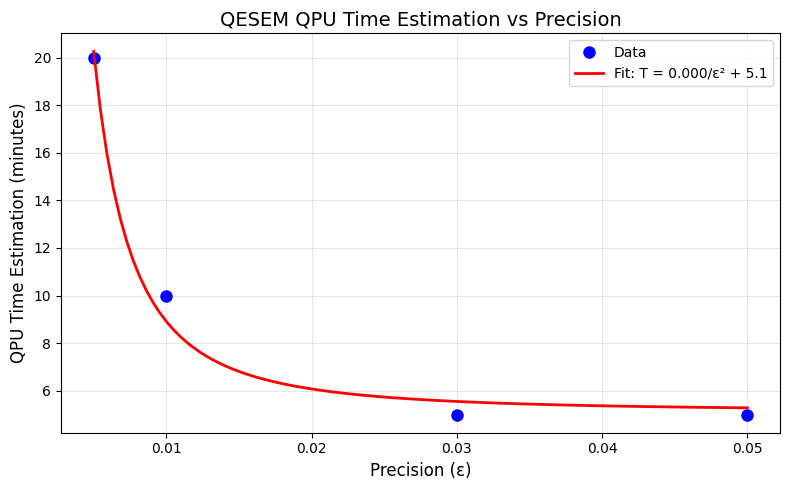

In [74]:
# Define the plotting function to visualize QPU time vs precision
def plot_qpu_time_vs_precision(precisions: list[float], time_estimations_sec: list[float], title_suffix: str = "") -> None:
    """
    Plot QPU time estimation vs precision with curve fitting

    Args:
        precisions: Array of precision values (ε)
        time_estimations_sec: Array of time estimations in seconds
        title_suffix: Optional suffix to add to the plot title
    """
    # Convert time estimations from seconds to minutes
    time_estimations_min = np.array(time_estimations_sec) / 60

    # Define the fitting function: T = A/precision^2 + B
    def fit_function(precisions: list[float], a: float, b: float) -> list[float]:
        return [a / (p**2) + b for p in precisions]

    # Perform the curve fit using time
    popt, _ = scipy.optimize.curve_fit(fit_function, precisions, time_estimations_min)
    a_fit, b_fit = popt

    # Create a smooth curve for plotting the fit
    precision_smooth = np.linspace(min(precisions), max(precisions), 100).tolist()
    time_fit = fit_function(precision_smooth, a_fit, b_fit)

    plt.figure(figsize=(8, 5))
    plt.plot(precisions, time_estimations_min, "o", markersize=8, color="blue", label="Data")
    plt.plot(
        precision_smooth,
        time_fit,
        "-",
        linewidth=2,
        color="red",
        label=f"Fit: T = {a_fit:.3f}/ε² + {b_fit:.1f}",
    )
    plt.xlabel("Precision (ε)", fontsize=12)
    plt.ylabel("QPU Time Estimation (minutes)", fontsize=12)
    plt.title(f"QESEM QPU Time Estimation vs Precision{title_suffix}", fontsize=14)

    plt.locator_params(axis="y", nbins=10)  # Increase number of y-axis ticks
    plt.grid(True, alpha=0.3)
    plt.legend()

    # Display fit parameters
    print("Fitted parameters:")
    print(f"A = {a_fit:.3f}")
    print(f"B = {b_fit:.2f}")
    print(f"Function: T = {a_fit:.3f}/ε² + {b_fit:.2f}")
    print(f"Data points: {len(precisions)}")

    plt.tight_layout()
    plt.show()


# Create the initial plot with Steps 2-5 data
plot_qpu_time_vs_precision(precisions_ex4, time_estimations)

And indeed we can see the expected functional dependence of:
$$T_{QPU} \approx \frac{\tilde{A}}{\epsilon^2} + B$$
Where:
- $\tilde A={A} \times e^{C \times IF \times V_{active}}$
- $A$ is a constant that depends on the circuit and the expectation value
- $B$ is overhead due to gate optimization and error characterization
- $C$ is a constant between 2-4 that depends on the details of the error mitigation method.

### Step 6: Execute with error mitigation

Now let's run the actual QESEM error mitigation on our circuit.

<div class="alert alert-block alert-success">

<b> Exercise 4.2:</b>

Look at the results of the QPU time vs precision graph above and think which precision you would like for your full execution (on a noisy simulator).
Complete the QESEM job parameters accordingly.
We will run an empirical time estimation for your desired precision to predict QPU resource requirements before running the full QESEM mitigation.

</div>

<div class="alert alert-block alert-info">
<b>Tip:</b> Use a moderate precision for reasonable execution time while still demonstrating the mitigation capabilities.

In [75]:
precision_ex4_2 = 0.04
circuit_ex4_2 = circ_ex4
observables_ex4_2 = [observable_ex4]
backend_ex4_2 = "fake_fez"
empirical_time_estimation_ex4_2 = True

### Test parameters

In [76]:
message = grader.grade_ex_4_2(
    precision_ex4_2=precision_ex4_2,
    circuit_ex4_2=circuit_ex4_2,
    observables_ex4_2=observables_ex4_2,
    backend_ex4_2=backend_ex4_2,
    empirical_time_estimation_ex4_2=empirical_time_estimation_ex4_2,
)
print(message)

Congratulations! 🎉 Your answer is correct.


### Start a job only if parameter check passed

In [77]:
if message == grader.CORRECT_MESSAGE:  # Run the job only if parameters are correct
    # Start a job
    # Get time estimation first (quick empirical check)
    job_ex4_2 = qedma_client.create_job(
        circuit=circuit_ex4_2,
        observables=observables_ex4_2,
        precision=precision_ex4_2,
        backend=backend_ex4_2,
        empirical_time_estimation=empirical_time_estimation_ex4_2,
    )

    print(f"Time estimation job submitted: {job_ex4_2.job_id}")
    print(f"with precision: {precision_ex4_2}")

else:
    print(message)
    print("Parameter check failed. Job did not start.")

2026-01-27 15:35:05.059 | INFO     | Submitting new job
2026-01-27 15:35:07.310 | INFO     | [d2d6bfb6686f4c638f7377dc754d951e] New job created
Time estimation job submitted: d2d6bfb6686f4c638f7377dc754d951e
with precision: 0.04


<a id="tips"></a>
<div class="alert alert-block alert-info">

<b> Tip:</b> Use this code cell to check your job's status.

In [81]:
qedma_client.get_job(job_ex4_2.job_id).status

2026-01-27 15:41:20.944 | INFO     | Querying jobs details. jobs_ids: ['d2d6bfb6686f4c638f7377dc754d951e']


<JobStatus.ESTIMATED: 'ESTIMATED'>

Extract the time estimation from Step 6a and add it to our precision vs. QPU time graph to see how the new data point fits the T ∝ 1/ε² relationship.

2026-01-27 15:42:44.389 | INFO     | [d2d6bfb6686f4c638f7377dc754d951e] Empirical time estimation: [5.0 minutes]
Step 6 time estimation: 300 seconds

Updated graph with Step 6 data point:
Fitted parameters:
A = 0.000
B = 5.03
Function: T = 0.000/ε² + 5.03
Data points: 5


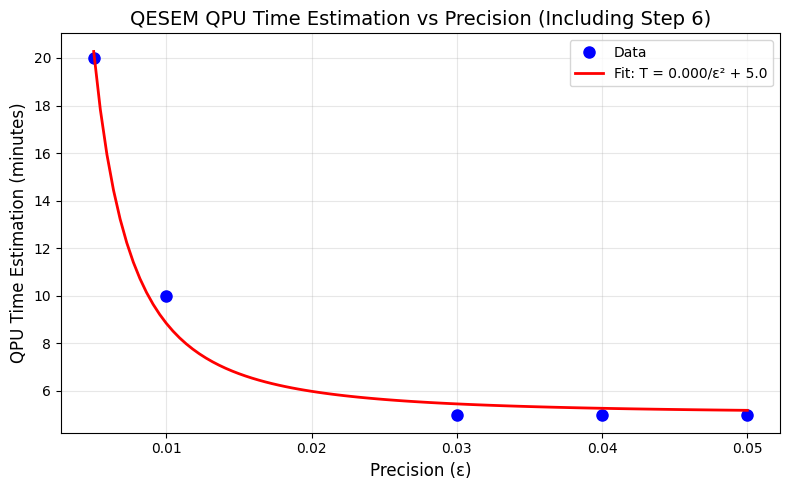

In [82]:
# Get the time estimation result
time_est_result = qedma_client.wait_for_time_estimation(job_ex4_2.job_id)
step6_time_estimation = time_est_result.seconds

print(f"Step 6 time estimation: {step6_time_estimation} seconds")

# Add the new data point to existing arrays
precisions_updated = precisions_ex4 + [precision_ex4_2]
time_estimations_updated = time_estimations + [step6_time_estimation]

# Plot the updated graph with the new data point
print("\nUpdated graph with Step 6 data point:")
plot_qpu_time_vs_precision(precisions_updated, time_estimations_updated, " (Including Step 6)")

<div class="alert alert-block alert-success">

<b> Exercise 4.3:</b>

If you are satisfied with the time estimation go ahead and run the full QESEM error mitigation on our 5-qubit, 10-step Kicked Ising circuit with precision ε. In a case of real QPU, This will take QPU time according to your estimation result.
Complete the QESEM job parameters accordingly.

</div>

<a id="tips"></a>
<div class="alert alert-block alert-info">

<b> Tip:</b> Use "max_execution_time" option, this allows you to limit the QPU time, as `datetime.timedelta`. After the time limit is reached, QESEM stops sending new circuits. Circuits that have already been sent continue running, you can see detailed explanation [here](https://docs.qedma.io/advanced_settings/).
Note: QESEM will end its run when it reaches the target precision or when it reaches max_execution_time, whichever comes first.
We will define max execution time as 3 minutes, which is enough for the 5-qubit, 10-step Kicked Ising circuit with precision ε=0.04 according to our time estimation.

<div class="alert alert-block alert-warning">
<b>Warning:</b> The QPU time estimation changes from one backend to another. Therefore, when executing QESEM, make sure to run it on the same backend that was selected when obtaining the QPU time estimation.

In [83]:
max_qpu_time_ex4_3 = datetime.timedelta(minutes=3)

### Test parameters

In [84]:
message = grader.grade_ex_4_3(max_qpu_time_ex4_3=max_qpu_time_ex4_3)
print(message)

Congratulations! 🎉 Your answer is correct.


### Start a job only if parameter check passed

In [85]:
if message == grader.CORRECT_MESSAGE:  # Run the job only if parameters are correct
    # Start a job
    # Submit actual mitigation job
    qedma_client.start_job(job_ex4_2.job_id, max_qpu_time=max_qpu_time_ex4_3)

    print(f"QESEM mitigation job submitted: {job_ex4_2.job_id}")
    print("Job is running... This may take several minutes.")

else:
    print(message)
    print("Parameter check failed, job did not start.")

2026-01-27 15:43:08.371 | INFO     | [d2d6bfb6686f4c638f7377dc754d951e] Starting job
QESEM mitigation job submitted: d2d6bfb6686f4c638f7377dc754d951e
Job is running... This may take several minutes.


<a id="tips"></a>
<div class="alert alert-block alert-info">

<b> Tip:</b> Use this code cell to check your job's status.

In [89]:
qedma_client.get_job(job_ex4_2.job_id).status

2026-01-27 15:47:59.418 | INFO     | Querying jobs details. jobs_ids: ['d2d6bfb6686f4c638f7377dc754d951e']


<JobStatus.SUCCEEDED: 'SUCCEEDED'>

Extract and analyze the QESEM results, comparing ideal, noisy, and error-mitigated expectation values to demonstrate the effectiveness of QESEM.


In [90]:
# Read and analyze results
print("Reading QESEM results...")

# Get the mitigated results
qesem_job_results = qedma_client.wait_for_job_complete(job_ex4_2.job_id)
print("Job completed successfully!")

# Extract results for our observable (first circuit, first observable)
circuit_result = qesem_job_results.results[0]  # First circuit result
observable, result = circuit_result[0]  # First (observable, result) pair

mitigated_expectation = result.qesem.value
mitigated_std = result.qesem.error_bar

# Get unmitigated results for comparison
noisy_expectation = result.unmitigated.value
noisy_std = result.unmitigated.error_bar

# Calculate ideal value for comparison
ideal_expectation = qiskit.quantum_info.Statevector(circ_ex4).expectation_value(observable_ex4).real

# Display comprehensive results summary
print("\n" + "=" * 60)
print("EXERCISE 4 - QESEM RESULTS SUMMARY")
print("=" * 60)
print(f"Observable: Global Z measurement (Z^⊗{n_qubits_ex4})")
print(f"Circuit: {n_steps_ex4}-step Kicked Ising, {n_qubits_ex4} qubits")
print(f"Precision target: {precision_ex4_2}")
print("-" * 60)
print(f"Ideal value:         {ideal_expectation:.6f}")
print(f"Unmitigated value:   {noisy_expectation:.6f} ± {noisy_std:.6f}")
print(f"QESEM value:         {mitigated_expectation:.6f} ± {mitigated_std:.6f}")
print("-" * 60)
print(f"Unmitigated error:   {abs(noisy_expectation - ideal_expectation):.6f}")
print(f"QESEM error:         {abs(mitigated_expectation - ideal_expectation):.6f}")
print(f"Error reduction:     {abs(noisy_expectation - ideal_expectation)/abs(mitigated_expectation - ideal_expectation if mitigated_expectation != ideal_expectation else 1):.1f}x")
print("-" * 60)
print(f"QESEM within target precision: {'✓' if abs(mitigated_expectation - ideal_expectation) <= precision_ex4_2 else '✗'}")
print("-" * 60)
# Additional detailed metrics
print(f"Total QPU time: \n {qesem_job_results.total_execution_time.seconds:.2f} seconds")
print(f"Gates fidelity measured during the experiment: \n {qesem_job_results.execution_details.gate_fidelities}")
print(f"Total shots / mitigation shots: \n {qesem_job_results.execution_details.total_shots} / {qesem_job_results.execution_details.mitigation_shots}")
print("=" * 60)

Reading QESEM results...
2026-01-27 15:48:03.279 | INFO     | [d2d6bfb6686f4c638f7377dc754d951e] step: [Queued]
2026-01-27 15:48:03.279 | INFO     | [d2d6bfb6686f4c638f7377dc754d951e] step: [Initial Transpilation]
2026-01-27 15:48:03.280 | INFO     | [d2d6bfb6686f4c638f7377dc754d951e] step: [Qubit Selection]
2026-01-27 15:48:03.280 | INFO     | [d2d6bfb6686f4c638f7377dc754d951e] step: [Calibration]
2026-01-27 15:48:03.280 | INFO     | [d2d6bfb6686f4c638f7377dc754d951e] step: [Characterization]
2026-01-27 15:48:03.281 | INFO     | [d2d6bfb6686f4c638f7377dc754d951e] step: [Batch Mitigation #1]
2026-01-27 15:48:13.637 | INFO     | [d2d6bfb6686f4c638f7377dc754d951e] Final results: [[[(<SparseObservable with 1 term on 5 qubits: (1+0j)(Z_4 Z_3 Z_2 Z_1 Z_0)>, QesemObservableResult(unmitigated=ExpectationValue(value=0.3894, error_bar=0.008959675746012476), noise_scaling=NoiseScalingResult(scaling_method='QESEM', results_with_REM=[ScaleExpectationValue(value=0.49101803437457775, error_bar=0.021

# Additional information
If you have any questions or need further assistance, feel free to ask!
In order to get access to QESEM over real QPUs, please contact us at Qedma.

<b>Created by:</b> Yotam Lifshitz, Qedma. Email: Yotam.Lifshitz@qedm.com<br>
